In [83]:
import numpy as np
from astropy.modeling.models import Gaussian2D
from photutils.datasets import make_noise_image
import pandas as pd
from astropy.nddata import CCDData
import numpy as np
from matplotlib import pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS

In [102]:
#Load the image and make a variable for final results
file_path = "cropped_host_galaxies/20210410D_flux.fits"
final_results = pd.DataFrame()
final_results["ellip"] = []
final_results["ellip_err"] = []

In [103]:
# Save the image data and crop the image if needed
hdu = fits.open(file_path)
wcs = WCS(hdu[0].header)
data = np.array(hdu[0].data, dtype=np.float64)
hdu.info()

Filename: cropped_host_galaxies/20210410D_flux.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      24   (25, 31)   float32   


In [104]:
#Make geometry and aperture of the FRB host galaxu with the good values of x0, y0, sma, eps and pa (good to start with guess values from the image)
from photutils.isophote import Ellipse
from photutils.aperture import EllipticalAperture
from photutils.isophote import EllipseGeometry

geometry = EllipseGeometry(x0=25, y0=22, sma=8, eps = 0.7, pa=1)
aper = EllipticalAperture((geometry.x0, geometry.y0), geometry.sma, geometry.sma * (1 - geometry.eps), geometry.pa)

C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


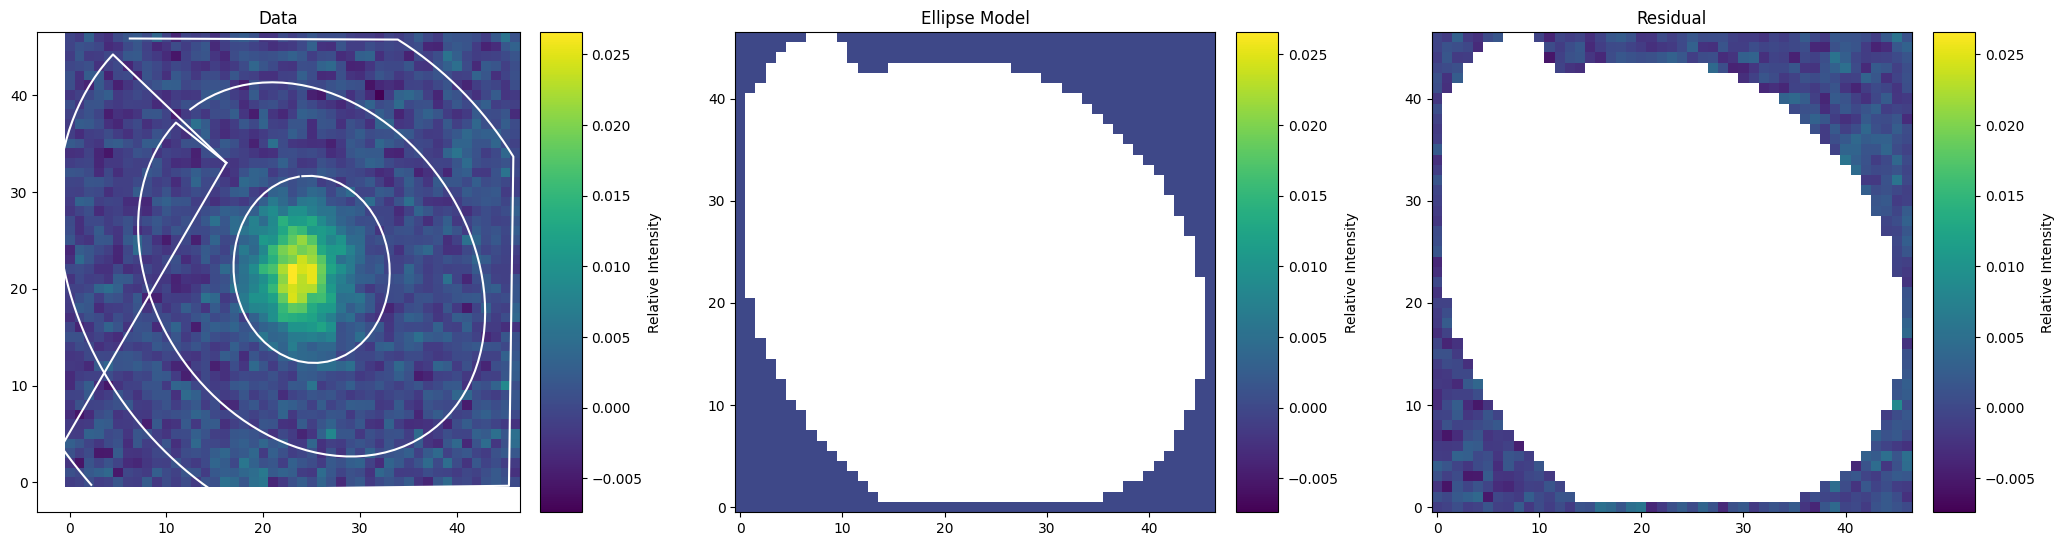

In [101]:
#Make an isophot model of the galaxy and plot the data, model and residual
from photutils.isophote import build_ellipse_model

ellipse = Ellipse(data, geometry)
isolist = ellipse.fit_image(
    nclip=1, 
    step=0.1,        # Grow slowly
    fix_center=True, # Stabilize the fit (crucial for faint galaxies)
    maxsma=60.0      # Stop before hitting the edge
)

model_image = build_ellipse_model(data.shape, isolist)
residual = data - model_image

fig, (ax1, ax2, ax3) = plt.subplots(figsize=(21, 5), nrows=1, ncols=3)
fig.subplots_adjust(left=0.04, right=0.98, bottom=0.02, top=0.98)

vmin = data.min()
vmax = data.max()

# Data with colorbar
im1 = ax1.imshow(data, origin='lower', vmin=vmin, vmax=vmax)
ax1.set_title('Data')
pos = ax1.get_position()
cax1 = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height])
fig.colorbar(im1, cax=cax1, label='Relative Intensity')

smas = np.linspace(10, 50, 5)
for sma in smas:
    iso = isolist.get_closest(sma)
    x, y = iso.sampled_coordinates()
    ax1.plot(x, y, color='white')

# Ellipse Model with colorbar
im2 = ax2.imshow(model_image, origin='lower', vmin=vmin, vmax=vmax)
ax2.set_title('Ellipse Model')
pos = ax2.get_position()
cax2 = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height])
fig.colorbar(im2, cax=cax2, label='Relative Intensity')

# Residual with colorbar
im3 = ax3.imshow(residual, origin='lower', vmin=vmin, vmax=vmax)
ax3.set_title('Residual')
pos = ax3.get_position()
cax3 = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.02, pos.height])
fig.colorbar(im3, cax=cax3, label='Relative Intensity')

plt.show()

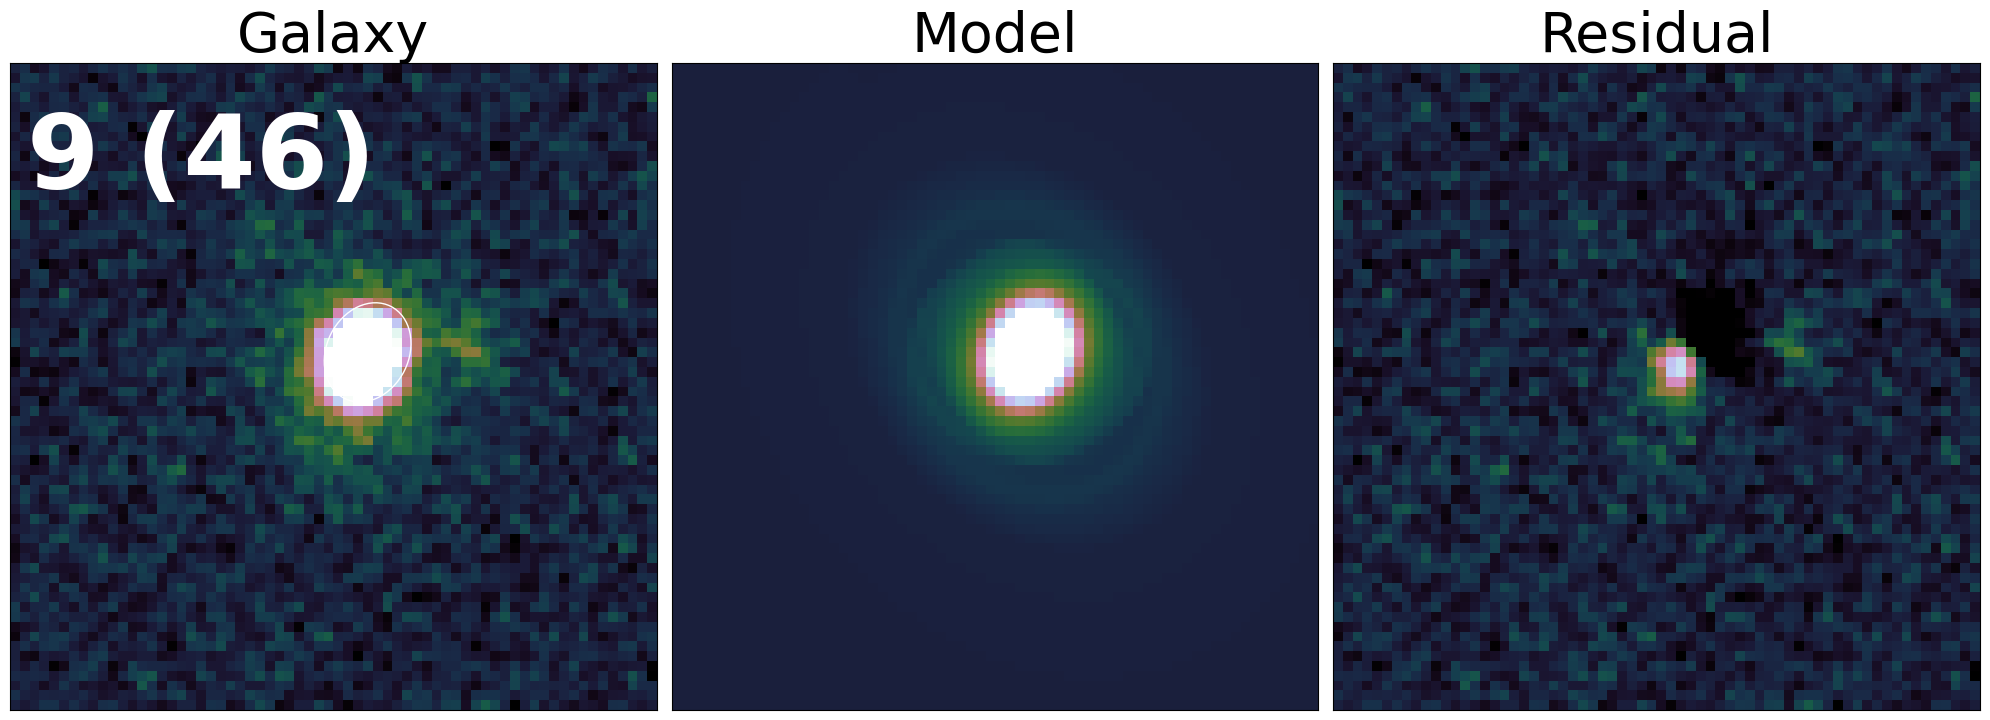

72.77202476935234


In [ ]:
import matplotlib.cm as cm
from astropy.wcs import WCS
from astropy.io import fits
from astropy.visualization import ZScaleInterval
from scipy.ndimage import gaussian_filter, convolve


hdu = fits.open(file_path)[0]
wcs = WCS(hdu.header)


#Find our half-light isophote from our list of isophote fits
found = False
for isophote in isolist:
  try:
    if isophote.tflux_e >= (isolist.tflux_e[-1])/2 and not found:
      found=True
      result = isophote
  except:
    pass

#Plot the half light isophote
aper2 = EllipticalAperture((result.x0, result.y0), result.sma,result.sma * (1 - result.eps), result.pa)
#make our figure
fig = plt.figure(figsize=(20,7))

#WCS works differently for PS1 and DESI, so we try both
try:
  ax1=fig.add_subplot(1,3,1,projection=wcs)
  ax2=fig.add_subplot(1,3,2,projection=wcs)
  ax3=fig.add_subplot(1,3,3,projection=wcs)
except:
  ax1=fig.add_subplot(1,3,1,projection=wcs[0])
  ax2=fig.add_subplot(1,3,2,projection=wcs[0])
  ax3=fig.add_subplot(1,3,3,projection=wcs[0])

# vmin = data.min()
# vmax = data.max()
zscale = ZScaleInterval(contrast=0.1)
vmin, vmax = zscale.get_limits(data)

#Plot the image and half light isophote
img1 = ax1.imshow(data, vmin = vmin , vmax = vmax, origin = 'lower', cmap='cubehelix')

aper2.plot(ax=ax1,color='white')

ax1.set_title("Galaxy", fontsize = 40)


#Label our graphs
ax1.set_xlabel(" ")
ax1.set_ylabel(" ")


ax2.set_xlabel(" ")
ax2.set_ylabel(" ")


ax3.set_xlabel(" ")
ax3.set_ylabel(" ")

# Assuming ax1, ax2, ax3 are your subplot axes

# Disable RA and Dec ticks and labels for ax1
ax1.coords[0].set_ticklabel_visible(False) # Disable RA tick labels
ax1.coords[1].set_ticklabel_visible(False) # Disable Dec tick labels
ax1.coords[0].set_ticks_visible(False) # Disable RA ticks
ax1.coords[1].set_ticks_visible(False) # Disable Dec ticks

# Repeat for ax2 and ax3
ax2.coords[0].set_ticklabel_visible(False) # Disable RA tick labels
ax2.coords[1].set_ticklabel_visible(False) # Disable Dec tick labels
ax2.coords[0].set_ticks_visible(False) # Disable RA ticks
ax2.coords[1].set_ticks_visible(False) # Disable Dec ticks

ax3.coords[0].set_ticklabel_visible(False) # Disable RA tick labels
ax3.coords[1].set_ticklabel_visible(False) # Disable Dec tick labels
ax3.coords[0].set_ticks_visible(False) # Disable RA ticks
ax3.coords[1].set_ticks_visible(False) # Disable Dec ticks


#Plot model and residual
img2 = ax2.imshow(model_image,vmin= vmin, vmax = vmax, cmap='cubehelix')

ax2.set_title("Model", fontsize = 40)


img3 = ax3.imshow(residual,vmin=  vmin, vmax = vmax, cmap='cubehelix')

ax3.set_title("Residual", fontsize = 40)

fig.tight_layout()
mid_x = -1.75
mid_y = 0.85
plt.text(mid_x, mid_y, '9 (46)', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, color = 'white', fontsize = 75, fontweight = 'bold')
#plt.savefig("FRB 20221012A_isophote.eps", bbox_inches="tight",dpi=200)
plt.show()

ellipse = Ellipse(data, geometry)
isolist = ellipse.fit_image()
isophote = ellipse.fit_isophote(sma=95.)
#Calculate and print the inclination angle with the given definition from photutils documentation
q = (1 - isophote.eps)
inclination_angle = np.degrees(np.arccos(np.sqrt((q**2-0.05**2)/(1-0.05**2))))
print(inclination_angle)